In [1]:
import torch
import sklearn  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('/gpfs0/bgu-benshimo/users/wavishay/thesis/avishai_work/ASV_utils/')
from ASV_utils.data_loading import load_data_all, load_data_male, load_data_female
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Gender recognization ASVSpoof2019:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# pip install pacmap
import pacmap


class class_time_embeddings_gender_classification:
    def __init__(self, path_to_time_embeddings, include_eval=False, include_dev=False):
        self.path_to_time_embeddings = path_to_time_embeddings

        (
            embedded_groups_1_1, embedded_groups_1_2, embedded_groups_1_3,
            chosen_labels_1_1_is_spoofed, chosen_labels_2_1_is_spoofed, chosen_labels_3_1_is_spoofed,
            chosen_labels_numeric_1_1, chosen_labels_numeric_2_1, chosen_labels_numeric_3_1,
            chosen_labels_1_1_attack_logical, chosen_labels_2_1_attack_logical, chosen_labels_3_1_attack_logical,
            chosen_labels_1_1_name, chosen_labels_2_1_name, chosen_labels_3_1_name,
            chosen_labels_1_1_speaker_id, chosen_labels_2_1_speaker_id, chosen_labels_3_1_speaker_id,
            chosen_labels_1_1_sex, chosen_labels_2_1_sex, chosen_labels_3_1_sex
        ) = load_data_all(self.path_to_time_embeddings, include_eval=include_eval, include_dev=include_dev)

        self.embedded_groups_1_1 = embedded_groups_1_1
        self.embedded_groups_1_2 = embedded_groups_1_2
        self.embedded_groups_1_3 = embedded_groups_1_3

        self.chosen_labels_1_1_is_spoofed = chosen_labels_1_1_is_spoofed
        self.chosen_labels_2_1_is_spoofed = chosen_labels_2_1_is_spoofed
        self.chosen_labels_3_1_is_spoofed = chosen_labels_3_1_is_spoofed

        self.chosen_labels_numeric_1_1 = chosen_labels_numeric_1_1
        self.chosen_labels_numeric_2_1 = chosen_labels_numeric_2_1
        self.chosen_labels_numeric_3_1 = chosen_labels_numeric_3_1

        self.chosen_labels_1_1_attack_logical = chosen_labels_1_1_attack_logical
        self.chosen_labels_2_1_attack_logical = chosen_labels_2_1_attack_logical
        self.chosen_labels_3_1_attack_logical = chosen_labels_3_1_attack_logical

        self.chosen_labels_1_1_name = chosen_labels_1_1_name
        self.chosen_labels_2_1_name = chosen_labels_2_1_name
        self.chosen_labels_3_1_name = chosen_labels_3_1_name

        self.chosen_labels_1_1_speaker_id = chosen_labels_1_1_speaker_id
        self.chosen_labels_2_1_speaker_id = chosen_labels_2_1_speaker_id
        self.chosen_labels_3_1_speaker_id = chosen_labels_3_1_speaker_id

        self.chosen_labels_1_1_sex = chosen_labels_1_1_sex
        self.chosen_labels_2_1_sex = chosen_labels_2_1_sex
        self.chosen_labels_3_1_sex = chosen_labels_3_1_sex

        self.train_embedding_pca = None
        self.dev_embedding_pca = None
        self.eval_embedding_pca = None

        self.train_embedding_tsne = None
        self.dev_embedding_tsne = None
        self.eval_embedding_tsne = None

        self.train_embedding_pacmap = None
        self.dev_embedding_pacmap = None
        self.eval_embedding_pacmap = None

        self.chosen_labels_1_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_1_1_attack_logical])
        self.chosen_labels_2_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_2_1_attack_logical])
        self.chosen_labels_3_1_attack_logical = pd.Series([x[0] for x in self.chosen_labels_3_1_attack_logical])

        self.chosen_labels_1_1_sex = pd.Series([x[0] for x in self.chosen_labels_1_1_sex])
        self.chosen_labels_2_1_sex = pd.Series([x[0] for x in self.chosen_labels_2_1_sex])
        self.chosen_labels_3_1_sex = pd.Series([x[0] for x in self.chosen_labels_3_1_sex])

        unique_labels = np.concatenate(
            [self.chosen_labels_1_1_attack_logical.unique(), self.chosen_labels_2_1_attack_logical.unique()],
            axis=0
        )
        colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
        self.label_to_color = {label: color for label, color in zip(unique_labels, colors)}

        self.chosen_labels_1_1_attack_logical_mapping = self.chosen_labels_1_1_attack_logical.map(self.label_to_color)
        self.chosen_labels_2_1_attack_logical_mapping = self.chosen_labels_2_1_attack_logical.map(self.label_to_color)

        self.frontsize = 16

    def create_pca(self, include_dev=False, include_eval=False):
        pca = PCA(n_components=3)
        pca.fit(self.embedded_groups_1_1)
        self.train_embedding_pca = pca.transform(self.embedded_groups_1_1)

        if include_dev:
            pca_dev = PCA(n_components=3)
            pca_dev.fit(self.embedded_groups_1_2)
            self.dev_embedding_pca = pca_dev.transform(self.embedded_groups_1_2)

        if include_eval:
            pca_eval = PCA(n_components=3)
            pca_eval.fit(self.embedded_groups_1_3)
            self.eval_embedding_pca = pca_eval.transform(self.embedded_groups_1_3)

        print("PCA explained variance ratio (train):", pca.explained_variance_ratio_)
        return self.train_embedding_pca, self.dev_embedding_pca, self.eval_embedding_pca

    def create_t_sne(self, include_dev=False, include_eval=False, **tsne_kwargs):
        tsne = TSNE(n_components=3, n_jobs=-1, **tsne_kwargs)
        self.train_embedding_tsne = tsne.fit_transform(self.embedded_groups_1_1)

        if include_dev:
            tsne_dev = TSNE(n_components=3, n_jobs=-1, **tsne_kwargs)
            self.dev_embedding_tsne = tsne_dev.fit_transform(self.embedded_groups_1_2)

        if include_eval:
            tsne_eval = TSNE(n_components=3, n_jobs=-1, **tsne_kwargs)
            self.eval_embedding_tsne = tsne_eval.fit_transform(self.embedded_groups_1_3)

        return self.train_embedding_tsne, self.dev_embedding_tsne, self.eval_embedding_tsne

    def create_pacmap(self, include_dev=False, include_eval=False, **pacmap_kwargs):
        """
        PaCMAP תומך ב-2D או 3D. כאן שמתי 3D כדי להתאים לגרפים שלך.
        pacmap_kwargs לדוגמה: n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0, random_state=42
        """
        reducer = pacmap.PaCMAP(n_components=3, **pacmap_kwargs)
        self.train_embedding_pacmap = reducer.fit_transform(self.embedded_groups_1_1)

        if include_dev:
            reducer_dev = pacmap.PaCMAP(n_components=3, **pacmap_kwargs)
            self.dev_embedding_pacmap = reducer_dev.fit_transform(self.embedded_groups_1_2)

        if include_eval:
            reducer_eval = pacmap.PaCMAP(n_components=3, **pacmap_kwargs)
            self.eval_embedding_pacmap = reducer_eval.fit_transform(self.embedded_groups_1_3)

        return self.train_embedding_pacmap, self.dev_embedding_pacmap, self.eval_embedding_pacmap

    def _get_embedding_by_method(self, split: str, method: str):
        method = method.lower()
        if method == "pca":
            return getattr(self, f"{split}_embedding_pca")
        if method in ("t_sne", "tsne"):
            return getattr(self, f"{split}_embedding_tsne")
        if method == "pacmap":
            return getattr(self, f"{split}_embedding_pacmap")
        raise ValueError("method must be one of: 'pca', 't_sne'/'tsne', 'pacmap'")

    def plotting_train(self, method="pca", plot_title="Train embeddings"):
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection="3d")

        label_to_color = {"male": "#1f77b4", "female": "#ff7f0e"}
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_1_1_sex])

        emb = self._get_embedding_by_method("train", method)
        if emb is None:
            raise RuntimeError(f"{method} embeddings for train are None. Run create_{method}() first.")

        ax.scatter(emb[:, 0], -emb[:, 1], -emb[:, 2], c=color_data, alpha=0.4)

        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=10)
            for _, color in label_to_color.items()
        ]
        ax.legend(handles, ["Male", "Female"], title="Labels", fontsize=self.frontsize, title_fontsize="22", loc="lower right")
        ax.set_title(plot_title, fontsize=28)
        ax.view_init(azim=75, elev=30)
        ax.set_xlabel(f"{method.upper()} 1", fontsize=22)
        ax.set_ylabel(f"{method.upper()} 2", fontsize=22)
        ax.set_zlabel(f"{method.upper()} 3", fontsize=22)
        plt.show()

    def plotting_dev(self, method="pca", plot_title="Dev embeddings"):
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection="3d")

        label_to_color = {"male": "#2ecc71", "female": "#e74c3c"}
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_2_1_sex])

        emb = self._get_embedding_by_method("dev", method)
        if emb is None:
            raise RuntimeError(f"{method} embeddings for dev are None. Run create_{method}(include_dev=True) first.")

        ax.scatter(emb[:, 0], -emb[:, 1], -emb[:, 2], c=color_data, alpha=0.4)

        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=10)
            for _, color in label_to_color.items()
        ]
        ax.legend(handles, ["Male", "Female"], title="Labels", fontsize=self.frontsize, title_fontsize="22", loc="lower right")
        ax.set_title(plot_title, fontsize=28)
        ax.view_init(azim=75, elev=30)
        ax.set_xlabel(f"{method.upper()} 1", fontsize=22)
        ax.set_ylabel(f"{method.upper()} 2", fontsize=22)
        ax.set_zlabel(f"{method.upper()} 3", fontsize=22)
        plt.show()

    def plotting_eval(self, method="pca", plot_title="Eval embeddings"):
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection="3d")

        label_to_color = {"male": "#8e44ad", "female": "#f1c40f"}
        color_data = np.array([label_to_color[label] for label in self.chosen_labels_3_1_sex])

        emb = self._get_embedding_by_method("eval", method)
        if emb is None:
            raise RuntimeError(f"{method} embeddings for eval are None. Run create_{method}(include_eval=True) first.")

        ax.scatter(emb[:, 0], -emb[:, 1], -emb[:, 2], c=color_data, alpha=0.4)

        handles = [
            plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=color, markersize=10)
            for _, color in label_to_color.items()
        ]
        ax.legend(handles, ["Male", "Female"], title="Labels", fontsize=self.frontsize, title_fontsize="22", loc="lower right")
        ax.set_title(plot_title, fontsize=28)
        ax.view_init(azim=75, elev=30)
        ax.set_xlabel(f"{method.upper()} 1", fontsize=22)
        ax.set_ylabel(f"{method.upper()} 2", fontsize=22)
        ax.set_zlabel(f"{method.upper()} 3", fontsize=22)
        plt.show()

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path

def save_pca_points_3d(
    obj,
    out_dir: str,
    include_dev: bool = True,
    include_eval: bool = True,
    save_mat: bool = True,
    save_npz: bool = True,
    save_csv_labels: bool = True,
    prefix: str = "",
):
    """
    obj = instance of class_time_embeddings_gender_classification
    Saves ONLY PCA 3D points + minimal labels
    """

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    if obj.train_embedding_pca is None:
        raise RuntimeError("Run create_pca() first.")

    if include_dev and obj.dev_embedding_pca is None:
        raise RuntimeError("Run create_pca(include_dev=True) first.")

    if include_eval and obj.eval_embedding_pca is None:
        raise RuntimeError("Run create_pca(include_eval=True) first.")

    if save_mat:
        try:
            import scipy.io as sio
        except ImportError as e:
            raise ImportError("pip install scipy") from e

    def _to_str(x):
        if isinstance(x, pd.Series):
            return x.astype(str).to_numpy()
        return np.array(x).astype(str)

    def _save(split, pca3, sex, speaker_id, is_spoofed):
        payload = {
            "pca3": np.asarray(pca3, dtype=np.float32),
            "sex": _to_str(sex),
            "speaker_id": _to_str(speaker_id),
            "is_spoofed": np.asarray(is_spoofed).reshape(-1),
        }

        if save_npz:
            np.savez_compressed(out_dir / f"{prefix}{split}_pca3.npz", **payload)

        if save_mat:
            sio.savemat(out_dir / f"{prefix}{split}_pca3.mat", payload, do_compression=True)

        if save_csv_labels:
            pd.DataFrame({
                "sex": payload["sex"],
                "speaker_id": payload["speaker_id"],
                "is_spoofed": payload["is_spoofed"],
            }).to_csv(out_dir / f"{prefix}{split}_labels.csv", index=False)

    # TRAIN
    _save(
        "train",
        obj.train_embedding_pca[:, :3],
        obj.chosen_labels_1_1_sex,
        obj.chosen_labels_1_1_speaker_id,
        obj.chosen_labels_1_1_is_spoofed,
    )

    # DEV
    if include_dev:
        _save(
            "dev",
            obj.dev_embedding_pca[:, :3],
            obj.chosen_labels_2_1_sex,
            obj.chosen_labels_2_1_speaker_id,
            obj.chosen_labels_2_1_is_spoofed,
        )

    # EVAL
    if include_eval:
        _save(
            "eval",
            obj.eval_embedding_pca[:, :3],
            obj.chosen_labels_3_1_sex,
            obj.chosen_labels_3_1_speaker_id,
            obj.chosen_labels_3_1_is_spoofed,
        )

    print(f"Saved PCA 3D points to: {out_dir.resolve()}")

In [5]:
time_original = class_time_embeddings_gender_classification('./Data/male_vs_female_DB_models/16_bits/none/all/',include_dev=True,include_eval=True)

time_original.create_pca(include_dev=True,include_eval=True)

save_pca_points_3d(
    time_original,
    out_dir="./saved_pca3/",
    include_dev=True,
    include_eval=True
)

PCA explained variance ratio (train): [0.92183425 0.05313814 0.00757516]
Saved PCA 3D points to: C:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\saved_pca3


PCA explained variance ratio (train): [0.92183425 0.05313814 0.00757516]


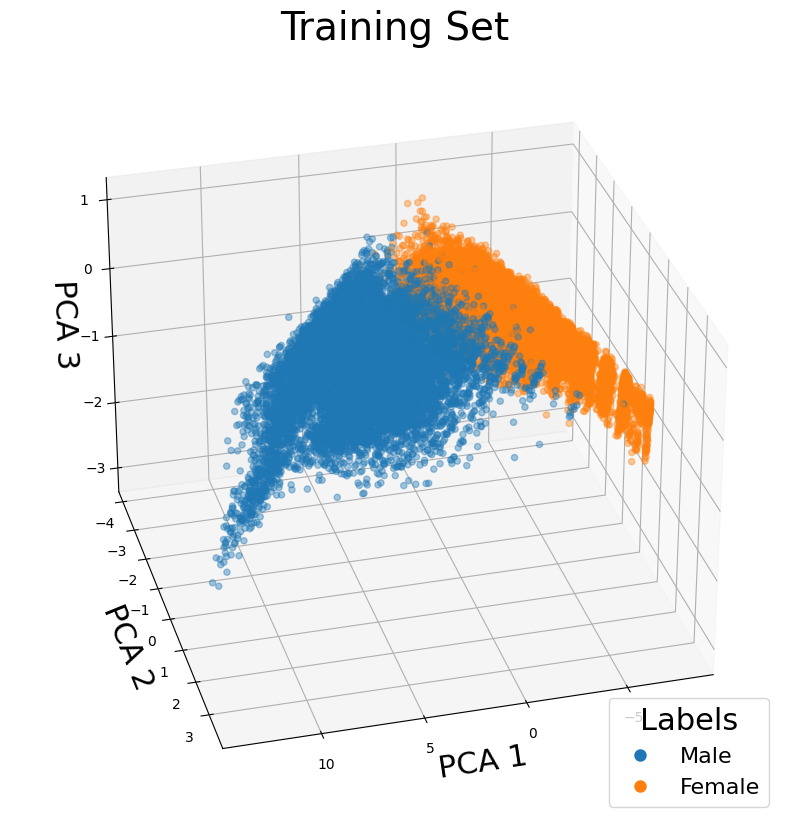

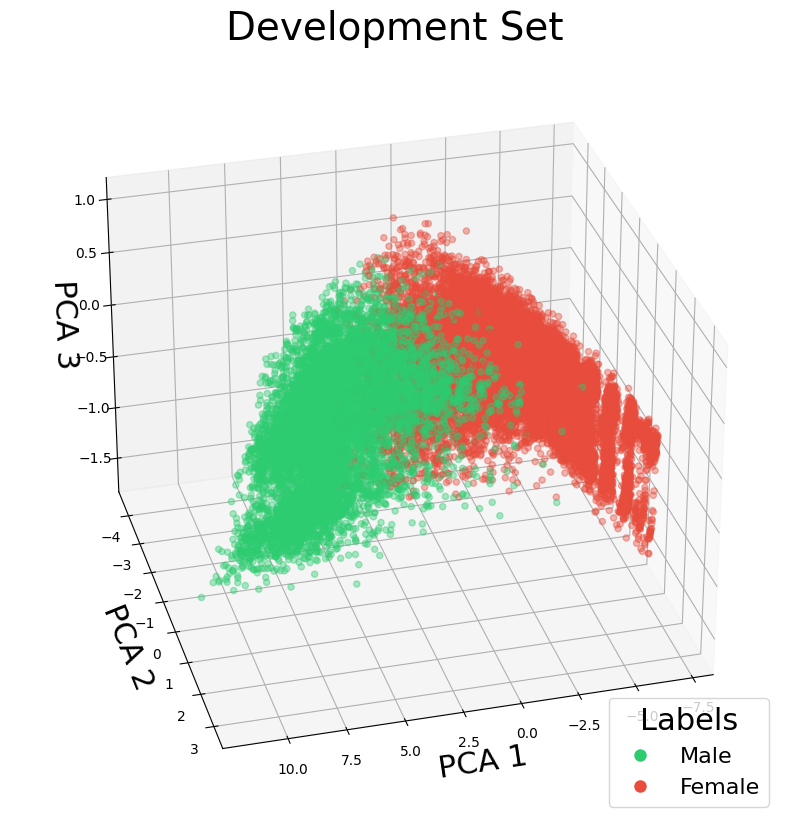

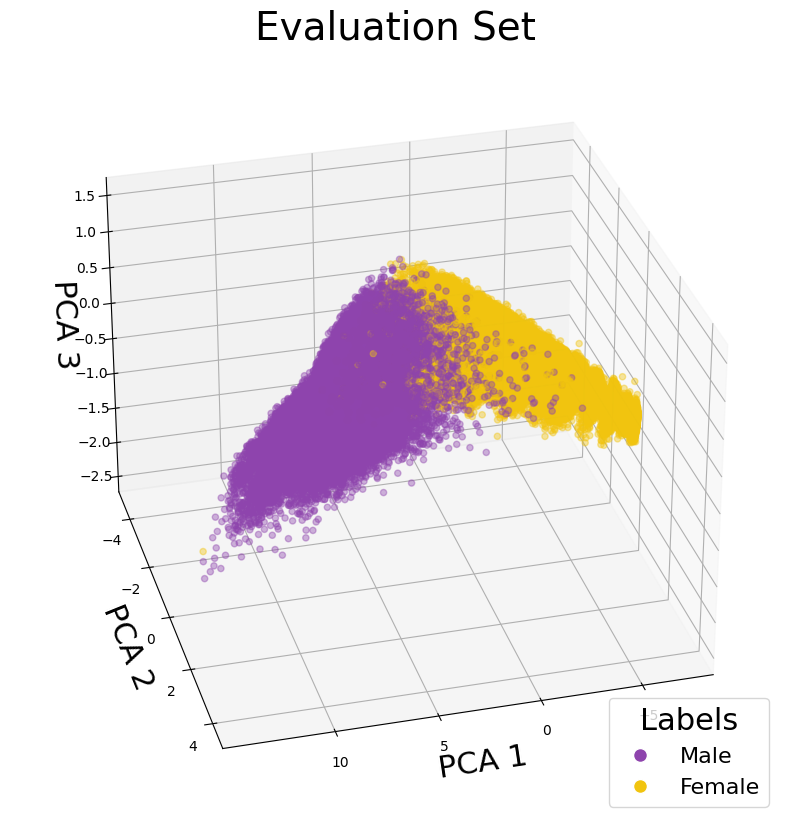

In [ ]:

time_original.plotting_train(method='pca',plot_title='Training Set')
time_original.plotting_dev(method='pca',plot_title='Development Set')
time_original.plotting_eval(method='pca',plot_title='Evaluation Set')


Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.
Note: `n_components != 2` have not been thoroughly tested.


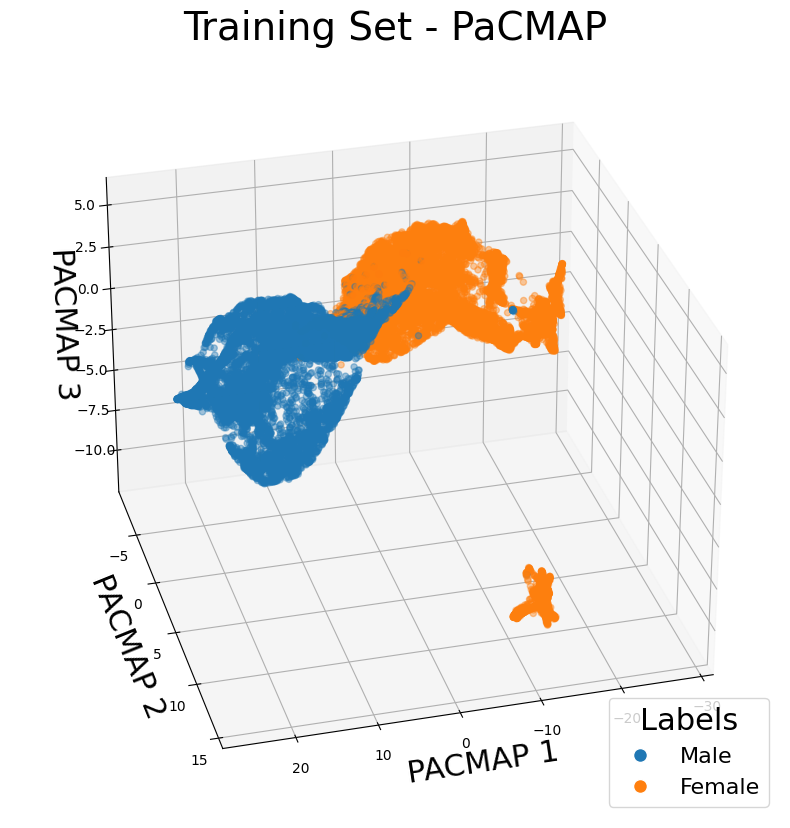

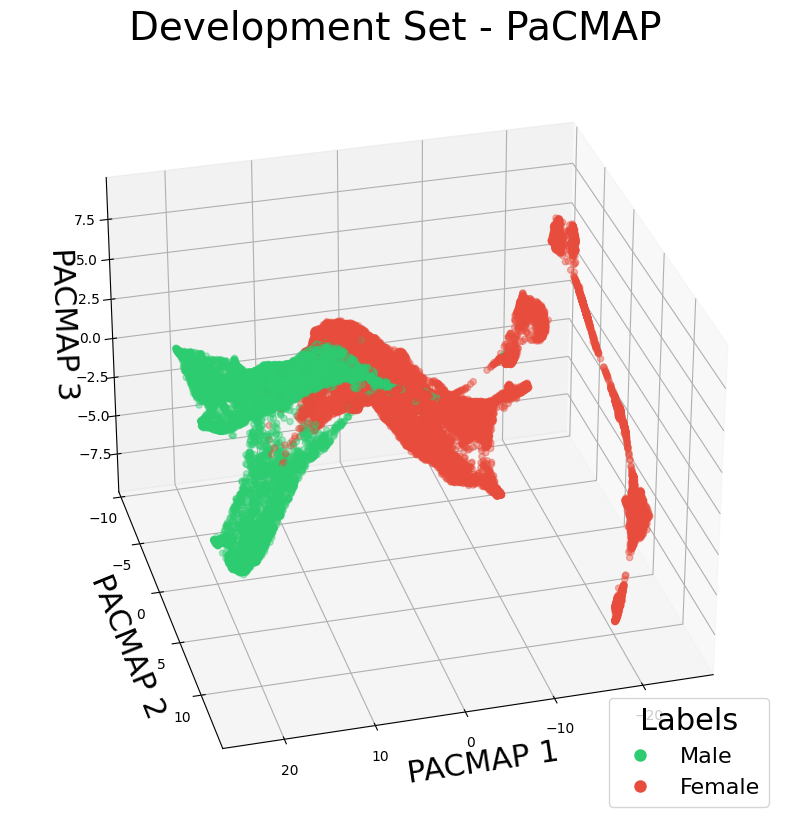

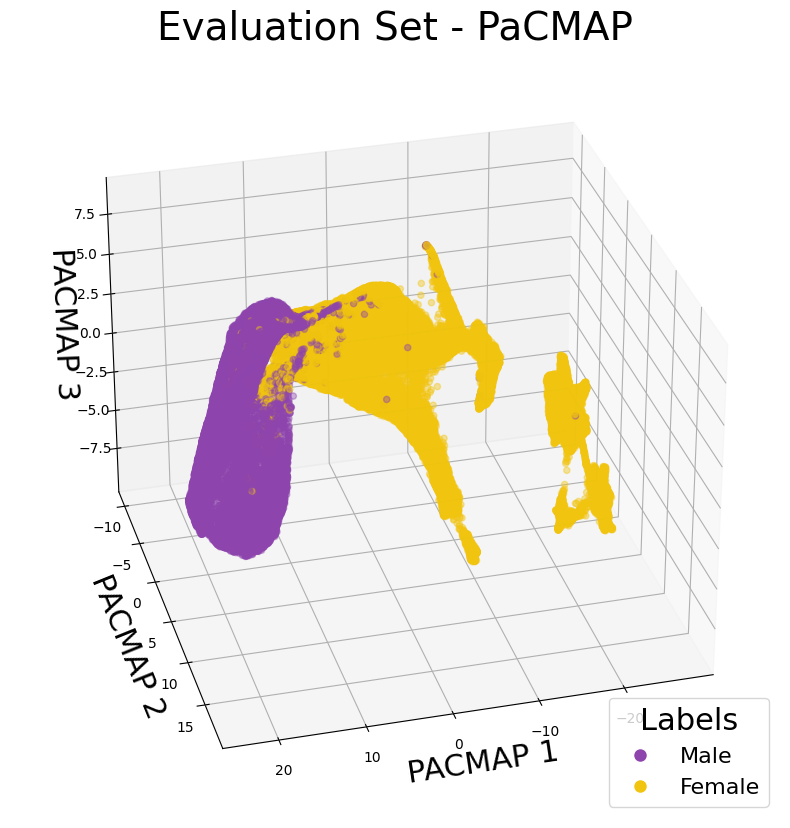

In [ ]:
time_original = class_time_embeddings_gender_classification(
    './Data/male_vs_female_DB_models/16_bits/none/all/',
    include_dev=True,
    include_eval=True
)

# יצירת embedding עם PaCMAP
time_original.create_pacmap(
    include_dev=True,
    include_eval=True,
    n_neighbors=10,
    MN_ratio=0.5,
    FP_ratio=2.0,
    random_state=42
)

# ציור
time_original.plotting_train(method='pacmap', plot_title='Training Set - PaCMAP')
time_original.plotting_dev(method='pacmap', plot_title='Development Set - PaCMAP')
time_original.plotting_eval(method='pacmap', plot_title='Evaluation Set - PaCMAP')